# RASCUNHO
Use esse arquivo para testra o que você está desenvolvendo. Ajuda muito conseguir visualizar o resultado do que você está fazendo. Você pode importar de core/ as funções que precisar e, quando estiver pronto, mover para o respectivo arquivo de core/

ex: fazer aqui o equalize() e depois mover para equalize.py

In [173]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from typing import Final
from numpy.typing import NDArray
from numpy import uint8, float64, intp
from matplotlib.figure import Figure
from matplotlib.axes import Axes
from PIL.Image import Image as IMG

## save() and load()

In [174]:
def load(path: str) -> IMG:
    return Image.open(path).convert('L') # isso converte para uma escala de cinza de 8 bits


img: IMG = load('lobao.jpg')

In [175]:
def save(img: Image.Image, path: str) -> None:
    img.save(path)

save(img, 'result.jpg')

### Tralhas

min: 0, max: 255


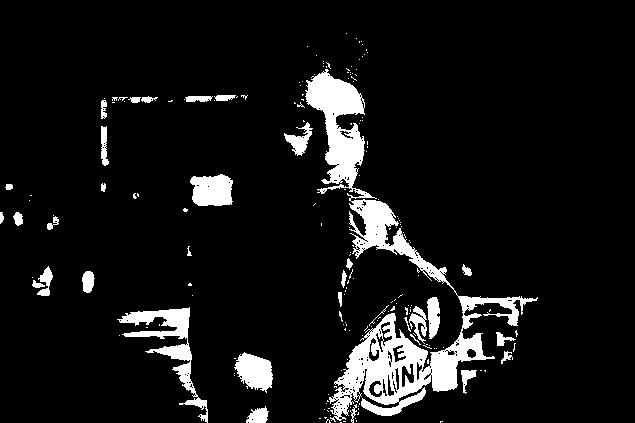

In [176]:
arr:    NDArray[uint8]   = np.array(img, dtype=np.uint8)

lut:    Final[list[int]] = [0 if i < 128 else 255 for i in range(256)]   # look up table: transformação ponto a ponto
img_bw: IMG              = img.point(lut, mode='L')                      # aplicando um tipo de threshold

print(f'min: {arr.min()}, max: {arr.max()}')
img_bw

## get_histogram()

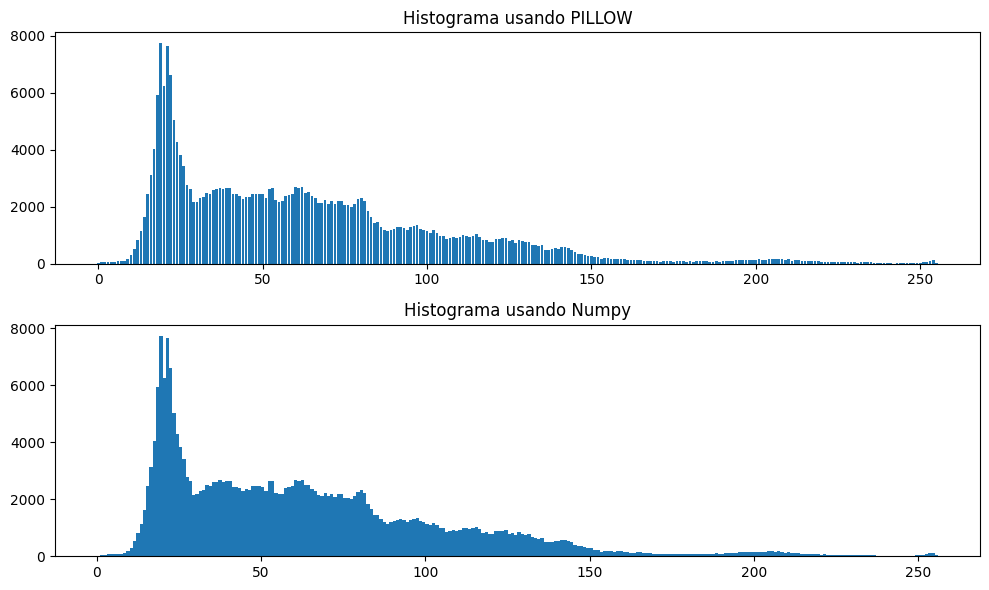

In [177]:
def get_histogram(img: IMG) -> Figure:
    
    fig: Figure = Figure(figsize=(10, 6))
    ax1: Axes = fig.add_subplot(2, 1, 1)
    ax2: Axes = fig.add_subplot(2, 1, 2)

    hist: list[int] = img.histogram()             # retorna valores discretos, por isso usa gráfico de barras
    ax1.set_title('Histograma usando PILLOW')
    ax1.bar(x=range(256), height=hist)

    arr: NDArray[uint8] = np.array(img, np.uint8) # retorna valores continuos, por isso usa histograma
    ax2.set_title('Histograma usando Numpy')
    ax2.hist(x=arr.ravel(), bins=256, range=(0,256))

    fig.tight_layout()

    return fig

fig: Figure = get_histogram(img)
fig

## compute_pdf()

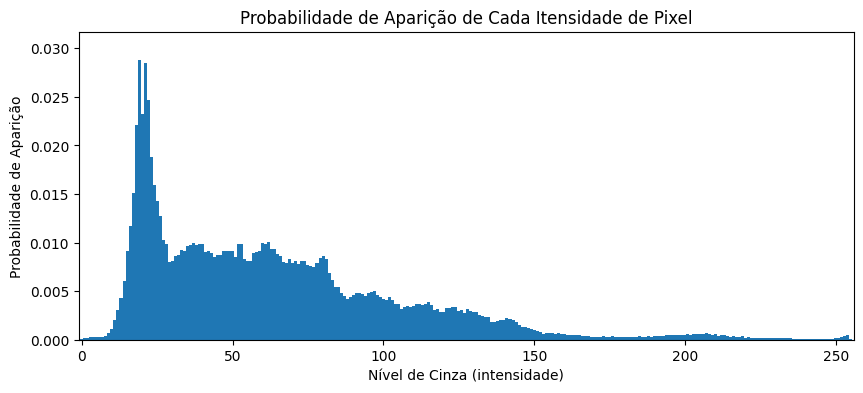

In [178]:
def compute_pdf(vector_image: NDArray[uint8]) -> tuple[Figure, NDArray[float64]]:

    vector_image = vector_image.astype(uint8)

    pixels_appears: NDArray[intp]    = np.bincount(vector_image.ravel(), minlength=256) # conta o valor abs de aparição de cada valor
    pdf_values:     NDArray[float64] = pixels_appears/vector_image.size

    fig: Figure = Figure(figsize=(10, 4))
    ax1: Axes   = fig.add_subplot(1, 1, 1)
    
    ax1.bar(np.arange(256), pdf_values, width=1)
    ax1.set_xlim(-1, 256)
    ax1.set_ylim(0, pdf_values.max()*1.1)
    ax1.set_title('Probabilidade de Aparição de Cada Itensidade de Pixel')
    ax1.set_xlabel('Nível de Cinza (intensidade)')
    ax1.set_ylabel('Probabilidade de Aparição')

    return (fig, pdf_values)


fig: Figure
pdf_values: NDArray[float64]
fig, pdf_values = compute_pdf(arr)
fig

## compute_cdf()

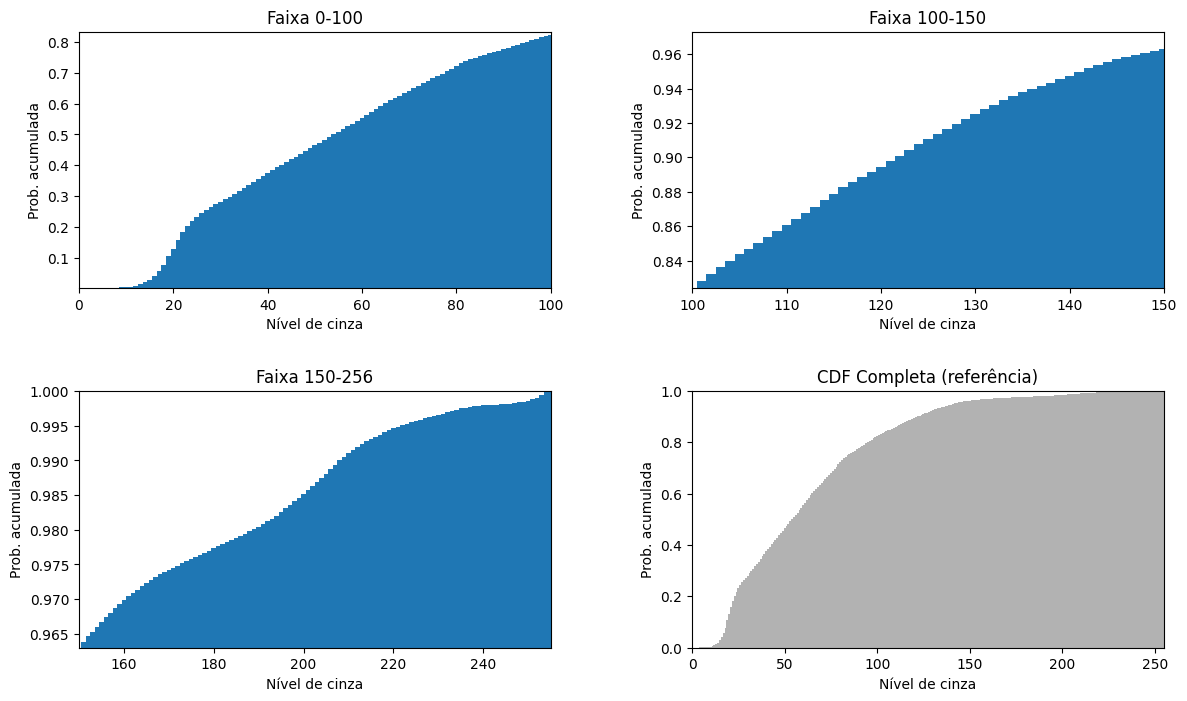

In [179]:
def compute_cdf(vector_image: NDArray[uint8]) -> tuple[Figure, NDArray[float64]]:
    
    pdf_values: NDArray[float64] = compute_pdf(vector_image)[1]
    cdf_values: NDArray[float64] = pdf_values.cumsum()

    fig: Figure = Figure(figsize=(14, 8))

    gs = gridspec.GridSpec(nrows=2, ncols=2, 
                           figure=fig, 
                           width_ratios=[1, 1], wspace=0.3, 
                           height_ratios=[1, 1], hspace=0.4)

    ax1: Axes = fig.add_subplot(gs[0,0])
    ax2: Axes = fig.add_subplot(gs[0,1])
    ax3: Axes = fig.add_subplot(gs[1,0])
    ax4: Axes = fig.add_subplot(gs[1,1])

    sections = [
        (ax1, 0, 101, 'Faixa 0-100'),
        (ax2, 100, 151, 'Faixa 100-150'),
        (ax3, 150, 256, 'Faixa 150-256'),
    ]

    for ax, start, end, title in sections:
        x = np.arange(start, end)
        ax.bar(x, cdf_values[start:end], width=1)

        ax.set_title(title)
        ax.set_xlabel("Nível de cinza")
        ax.set_ylabel("Prob. acumulada")
        ax.set_xlim(start, end - 1)
        ax.set_ylim(cdf_values[start], min(cdf_values[end - 1] + 0.01, 1.0))

    
    ax4.bar(np.arange(256), cdf_values, width=1, color="gray", alpha=0.6)
    ax4.set_title("CDF Completa (referência)")

    ax4.set_xlabel("Nível de cinza")
    ax4.set_ylabel("Prob. acumulada")
    ax4.set_xlim(0, 255)
    ax4.set_ylim(0, 1)

    return (fig, cdf_values)


fig: Figure
cdf_values: NDArray[float64]
fig, cdf_values = compute_cdf(arr)
fig